In [3]:
from typing import TypedDict, List, Union
from langchain_core.messages import HumanMessage, AIMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END  
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
class AgentState(TypedDict):
    messages: List[Union[HumanMessage, AIMessage]]

In [5]:
llm = ChatOpenAI(model_name="gpt-4o-mini")

In [6]:
def process(state: AgentState) -> AgentState:
    response = llm.invoke(state['messages'])
    print("AI Response:", response.content)
    state['messages'].append(AIMessage(content=response.content))
    return state


In [ ]:
graph = StateGraph(AgentState)
graph.add_node("process", process)
graph.add_edge(START, "process")
graph.add_edge("process", END)

app = graph.compile()

conversation_history = []

user_input = input("Enter : ")
while user_input.lower() not in ["quit", "exit"]:
    conversation_history.append(HumanMessage(content=user_input))
    result = app.invoke({"messages": conversation_history})
    conversation_history = result['messages']
    user_input = input("Enter : ")
    return state

AI Response: Hello! How can I assist you today?
AI Response: Today's date is October 5, 2023. How can I help you further?


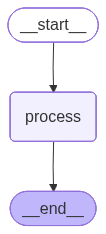

In [8]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))